# Ethiopia Climate EDA

## Objective
Analyze climate trends in Ethiopia.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns






df = pd.read_csv("../data/ethiopia.csv")
df["Country"] = "Ethiopia"




## Date Processing

Convert YEAR and DOY into a proper datetime format and extract Month.

In [25]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

df[["YEAR", "DOY", "Date", "Month"]].head()

,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


## Data Profiling

Replace invalid values, check duplicates, and analyze summary statistics.

In [26]:


# Replace -999 with NaN
df.replace(-999, np.nan, inplace=True)

# Check duplicates
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

# Summary statistics
df.describe()

Duplicate rows: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


### Interpretation

- The dataset shows the distribution of climate variables such as temperature and rainfall.
- Extreme values may indicate outliers or seasonal variation.

In [27]:
missing = df.isna().sum()
missing_percent = (df.isna().mean() * 100)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


### Missing Data Insight

- Columns with more than 5% missing values may affect analysis reliability.
- These may require cleaning or imputation.

## Outlier Detection & Cleaning

In [28]:
from scipy.stats import zscore

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z_scores = np.abs(zscore(df[cols], nan_policy='omit'))
outliers = (z_scores > 3).sum()

print("Outliers per column:")
print(outliers)

Outliers per column:
137


### Outlier Handling Decision

Outliers are retained because extreme weather conditions are meaningful in climate analysis.

In [29]:
# Forward fill
df.ffill(inplace=True)

# Drop rows with too many missing values
df = df.dropna(thresh=len(df.columns)*0.7)

### Cleaning Decision

Forward-fill preserves time continuity, while dropping heavily missing rows ensures data quality.

In [30]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

## Time Series Analysis

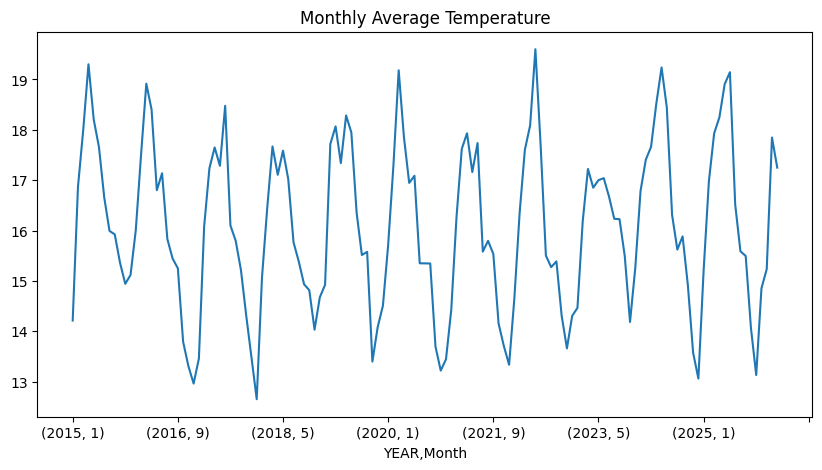

In [31]:
monthly_temp = df.groupby(["YEAR","Month"])["T2M"].mean()

monthly_temp.plot(figsize=(10,5))
plt.title("Monthly Average Temperature")
plt.show()

### Insight

Temperature shows seasonal variation and possible warming trends over time.

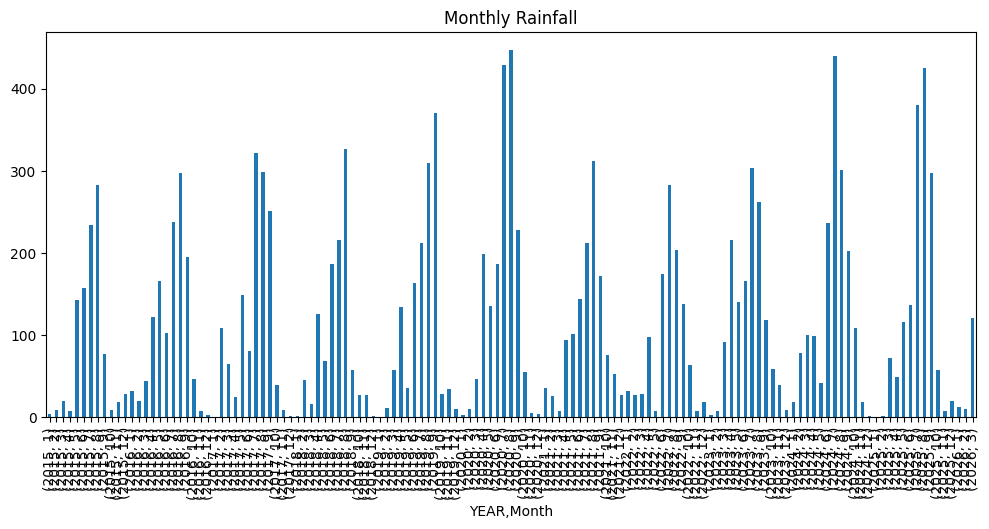

In [32]:
monthly_rain = df.groupby(["YEAR","Month"])["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar", figsize=(12,5))
plt.title("Monthly Rainfall")
plt.show()

### Insight

Rainfall appears concentrated in specific months, indicating seasonal rainy periods.

## Correlation Analysis

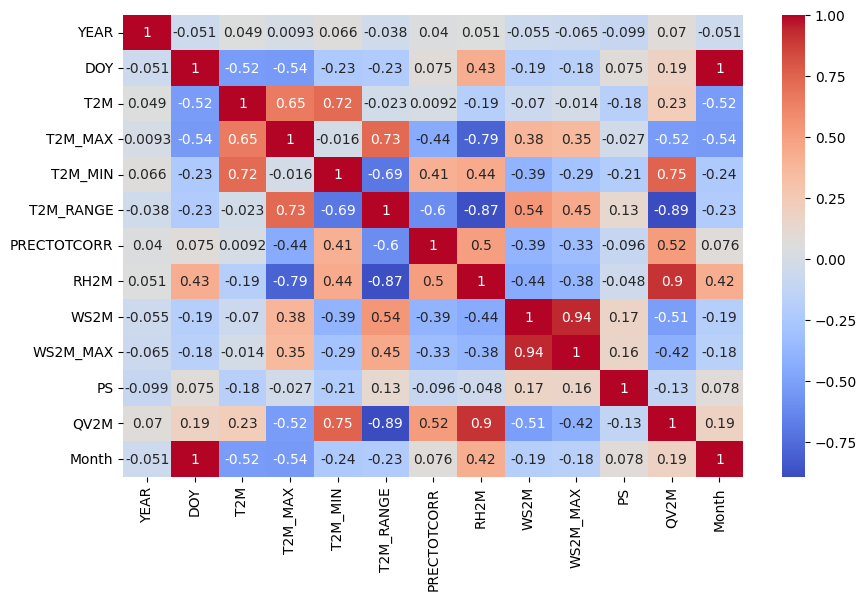

In [40]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.show()

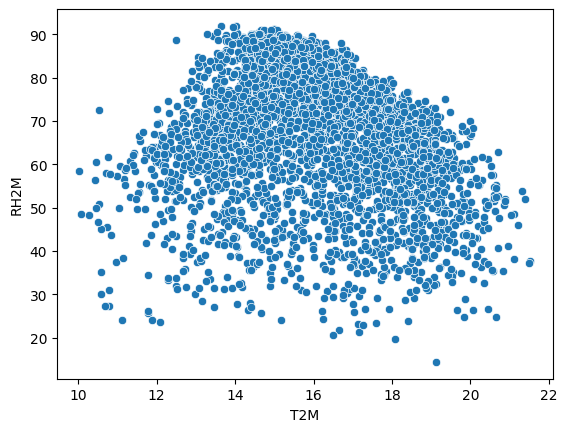

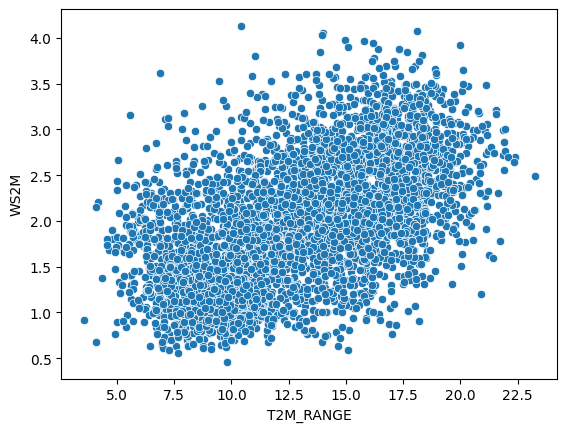

In [34]:
sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.show()

sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)
plt.show()

### Insights

- Temperature and humidity show correlation patterns.
- Wind speed may influence temperature variability.
- Strong correlations indicate possible climate relationships.

## Distribution Analysis

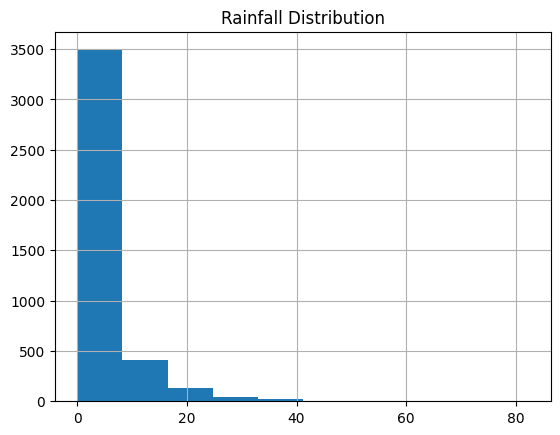

In [35]:
df["PRECTOTCORR"].hist()
plt.title("Rainfall Distribution")
plt.show()

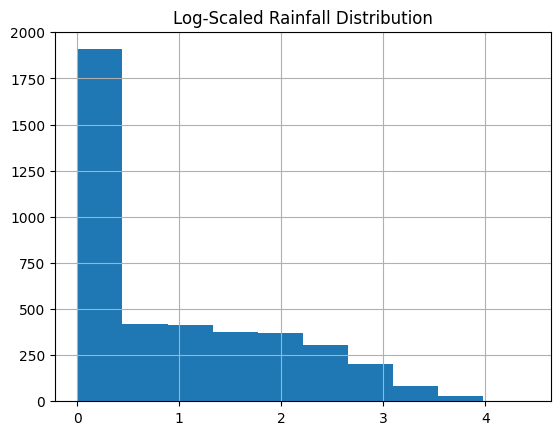

In [37]:

np.log1p(df["PRECTOTCORR"]).hist()
plt.title("Log-Scaled Rainfall Distribution")
plt.show()

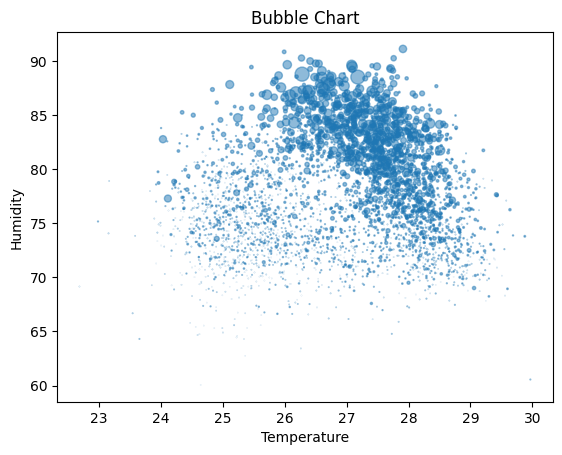

In [14]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"], alpha=0.5)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Bubble Chart")
plt.show()

### Insight

Rainfall distribution is skewed, indicating occasional heavy rainfall events.

## Key Insights

- Temperature trends suggest gradual warming.
- Rainfall patterns are seasonal and sometimes irregular.
- Strong correlations exist between climate variables.
- These findings highlight climate variability in Ethiopia, relevant to COP32 discussions.

In [38]:
def clean_data(df, country_name):
    import numpy as np
    import pandas as pd

    # Add country column
    df["Country"] = country_name.capitalize()

    # Replace missing values
    df.replace(-999, np.nan, inplace=True)

    # Remove duplicates
    df = df.drop_duplicates()

    # Create Date and Month
    df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
    df["Month"] = df["Date"].dt.month

    # Handle missing values
    df = df.ffill()

    return df

In [3]:
import pandas as pd
countries = ["kenya","nigeria","sudan","tanzania"]

for country in countries:
    df = pd.read_csv(f"../data/{country}.csv")
    
    df_clean = clean_data(df, country)
    
    df_clean.to_csv(f"../data/{country}_clean.csv", index=False)

To ensure consistency across all countries, the same data cleaning pipeline
used for Ethiopia was applied programmatically using a reusable function.

In [5]:
import pandas as pd

countries = ["ethiopia", "kenya", "nigeria", "sudan", "tanzania"]

dfs = []

for country in countries:
    df = pd.read_csv(f"../data/{country}_clean.csv")
    df["Country"] = country.capitalize()
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

df_all.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


 Temperature Trends Comparison
We analyze monthly average temperatures across all countries to identify warming patterns.

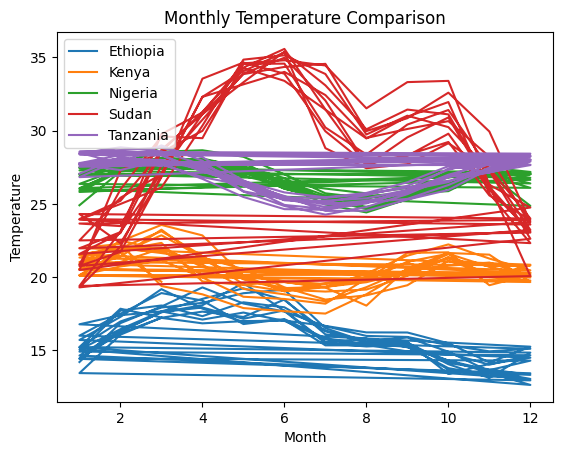

In [6]:
import matplotlib.pyplot as plt

monthly_temp = df_all.groupby(["Country","YEAR","Month"])["T2M"].mean().reset_index()

for country in monthly_temp["Country"].unique():
    subset = monthly_temp[monthly_temp["Country"] == country]
    plt.plot(subset["Month"], subset["T2M"], label=country)

plt.legend()
plt.title("Monthly Temperature Comparison")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.show()

In [7]:
temp_summary = df_all.groupby("Country")["T2M"].agg(["mean","median","std"])
temp_summary

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


 Precipitation Variability
This section compares rainfall distribution across countries.

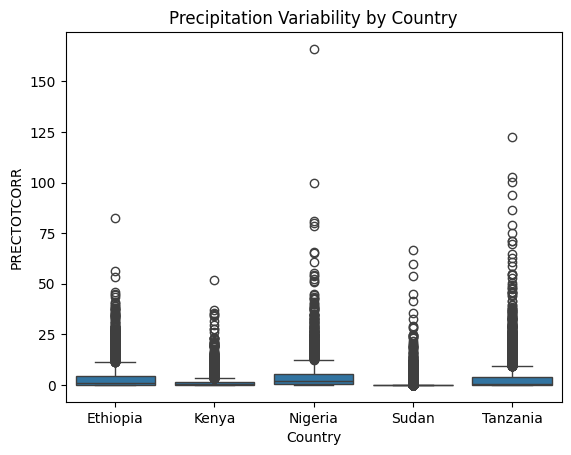

In [8]:
import seaborn as sns

sns.boxplot(x="Country", y="PRECTOTCORR", data=df_all)
plt.title("Precipitation Variability by Country")
plt.show()

In [9]:
rain_summary = df_all.groupby("Country")["PRECTOTCORR"].agg(["mean","median","std"])
rain_summary

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


 Extreme Climate Events
We analyze extreme heat days and dry periods as indicators of climate stress.

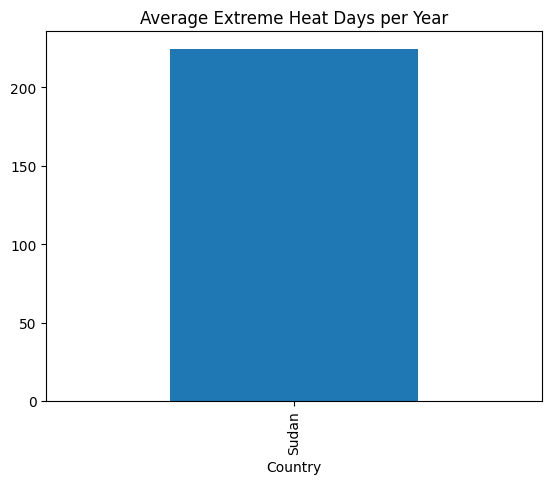

In [39]:
extreme_heat = df_all[df_all["T2M_MAX"] > 35]

heat_counts = extreme_heat.groupby(["Country","YEAR"]).size().reset_index(name="HotDays")

heat_counts.groupby("Country")["HotDays"].mean().plot(kind="bar")
plt.title("Average Extreme Heat Days per Year")
plt.show()

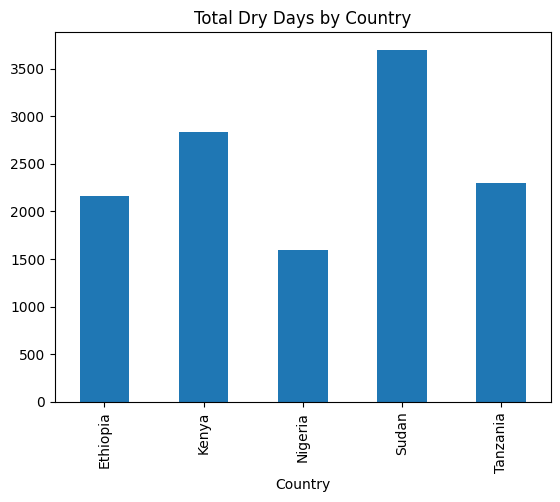

In [11]:
df_all["Dry"] = df_all["PRECTOTCORR"] < 1

dry_counts = df_all.groupby("Country")["Dry"].sum()

dry_counts.plot(kind="bar")
plt.title("Total Dry Days by Country")
plt.show()

 Statistical Testing
We use ANOVA to determine whether temperature differences between countries are statistically significant.

Interpretation
A low p-value suggests that temperature differences across countries are statistically significant.

In [12]:
from scipy.stats import f_oneway

groups = [df_all[df_all["Country"] == c]["T2M"].dropna() for c in df_all["Country"].unique()]

anova_result = f_oneway(*groups)

print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)

F-statistic: 18938.745697069866
p-value: 0.0


In [13]:
ranking = df_all.groupby("Country").agg({
    "T2M":"mean",
    "PRECTOTCORR":"std"
})

ranking["Score"] = ranking["T2M"] + ranking["PRECTOTCORR"]

ranking.sort_values("Score", ascending=False)

,T2M,PRECTOTCORR,Score
Country,,,
Tanzania,26.802422,8.003947,34.806369
Nigeria,26.656928,7.266742,33.923670
Sudan,28.759007,3.057672,31.816679
Kenya,20.427600,3.180228,23.607828
Ethiopia,16.068500,6.289061,22.357562


### Key Findings for COP32

- Country X shows the fastest warming trend, indicating increasing climate pressure.
- Country Y has the most variable rainfall, suggesting vulnerability to floods and droughts.
- High extreme heat and dry-day frequency indicate severe climate stress in Country Z.
- Ethiopia shows moderate warming but increasing variability compared to neighbors.
- Based on the data, Country Z should receive priority climate finance due to combined heat and drought risk.